# Cross-Validation for Financial Machine Learning

**ML4T Third Edition — Chapter 6: Strategy Definition**

**Docker image**: `ml4t`

This notebook builds cross-validation from first principles for time series:

1. **Decision-time admissibility** — the central design constraint
2. **Three dataset roles** — train, validation, and holdout test
3. **K-fold CV** — and why random shuffling fails for time series
4. **Walk-forward CV** — expanding and rolling windows
5. **Label buffer (purging)** — preventing forward-looking label leakage
6. **Feature buffer (embargo)** — preventing backward-looking feature leakage
7. **Calendar-aware CV** — trading days vs calendar days
8. **Nested walk-forward** — retuning across multiple test years
9. **Combinatorial purged CV (CPCV)** — multiple backtest paths
10. **Putting it together** — from config to protocol

**Book Reference**: Section 6.5 (Evaluation Protocol for Time Series)

**References**:
- López de Prado (2018). *Advances in Financial Machine Learning*, Ch. 7
- Bailey, Borwein, López de Prado, and Zhu (2014). "The Probability of Backtest Overfitting"

In [1]:
"""Cross-validation foundations for Chapter 6."""

import warnings
from math import comb

import exchange_calendars as xcals
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from matplotlib.patches import Patch, Rectangle
from ml4t.diagnostic.splitters import CombinatorialCV, WalkForwardCV
from ml4t.diagnostic.splitters.config import WalkForwardConfig
from plotly.subplots import make_subplots
from sklearn.model_selection import KFold

from utils.modeling import get_cv_config
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
N_VIZ = 504
SEED = 42

In [3]:
set_global_seeds(SEED)

---

## Data Setup

We use 12 years of NYSE trading sessions (2014–2025) throughout.

In [4]:
nyse = xcals.get_calendar("XNYS")
sessions = nyse.sessions_in_range("2014-01-01", "2025-12-31")
dates = pd.DatetimeIndex(sessions, tz="UTC")
df_dates = pd.DataFrame({"idx": np.arange(len(dates))}, index=dates)

print(f"NYSE sessions 2014–2025: {len(dates):,}")

NYSE sessions 2014–2025: 3,018


### Visualization Helper

In [5]:
def plot_splits(splits, dates, *, title="", figsize=(12, 3.5)):
    """Plot walk-forward splits as horizontal bars with real dates."""
    n_folds = len(splits)
    fig, ax = plt.subplots(figsize=figsize)

    for i, (tr, va) in enumerate(splits):
        y = n_folds - i
        tr_start, tr_end = dates[tr[0]], dates[tr[-1]]
        va_start, va_end = dates[va[0]], dates[va[-1]]

        # Detect purge gap (more than 1 index between train end and val start)
        gap = va[0] - tr[-1]

        ax.barh(y, tr_end - tr_start, left=tr_start, height=0.6, color="0.75", edgecolor="0.5")
        ax.barh(y, va_end - va_start, left=va_start, height=0.6, color="0.35", edgecolor="0.2")

        if gap > 2:
            ax.barh(
                y,
                va_start - tr_end,
                left=tr_end,
                height=0.6,
                color="0.9",
                edgecolor="0.7",
                hatch="//",
                linewidth=0.5,
            )

    ax.set_yticks(range(1, n_folds + 1))
    ax.set_yticklabels([f"Fold {n_folds - i}" for i in range(n_folds)])
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.set_title(title)

    handles = [
        Patch(facecolor="0.75", label="Training"),
        Patch(facecolor="0.35", label="Validation"),
    ]
    if any(va[0] - tr[-1] > 2 for tr, va in splits):
        handles.insert(1, Patch(facecolor="0.9", edgecolor="0.7", hatch="//", label="Label buffer"))
    ax.legend(handles=handles, loc="upper right")
    fig.tight_layout()
    return fig

---

## 1. Decision-Time Admissibility

The central question behind every CV design choice:

> **At decision time $t$, which labeled samples were actually available?**

Any sample whose label, feature, or selection criterion depends on
information unavailable at $t$ must be excluded from training.
Section 6.5 identifies five channels through which future information can
leak into past decisions:

| Leakage Channel | Example | Prevention |
|---|---|---|
| **Label leakage** | 21-day forward return overlaps validation | Label buffer (purging) |
| **Standardization leakage** | Z-scoring with full-sample mean/std | Expanding-window transforms |
| **Threshold leakage** | Percentile labels from full sample | Rolling percentile thresholds |
| **Survivorship leakage** | Training only on surviving firms | Rebalance universe per period |
| **Point-in-time leakage** | Fundamentals reported after decision | Conservative publication lag |

The CV schemes in this notebook operationalize the first channel (label
leakage via the **label buffer**) and flag where the others apply.

---

## 2. Three Dataset Roles

Before any experiment, partition data into three disjoint sets:

| Dataset | Role | When Accessed |
|---|---|---|
| **Training** | Fit model parameters | During training |
| **Validation** | Select hyperparameters, compare models | During development |
| **Holdout Test** | Final unbiased performance estimate | Once, at the end |

The **holdout test set is sealed** from the start. Using it for any
development decision contaminates the final estimate.

In [6]:
# Partition: Train 5Y | Validation 5Y | Holdout 2Y
train_end = pd.Timestamp("2018-12-31", tz="UTC")
val_end = pd.Timestamp("2023-12-31", tz="UTC")

train_mask = dates <= train_end
val_mask = (dates > train_end) & (dates <= val_end)
test_mask = dates > val_end

partition_df = pd.DataFrame(
    {
        "Period": ["Training", "Validation", "Holdout Test"],
        "Start": [
            dates[0].date(),
            dates[train_mask.sum()].date(),
            dates[train_mask.sum() + val_mask.sum()].date(),
        ],
        "End": [train_end.date(), val_end.date(), dates[-1].date()],
        "Trading Days": [train_mask.sum(), val_mask.sum(), test_mask.sum()],
    }
)
partition_df

,Period,Start,End,Trading Days
0,Training,2014-01-02,2018-12-31,1258
1,Validation,2019-01-02,2023-12-31,1258
2,Holdout Test,2024-01-02,2025-12-31,502


**Rule**: The holdout test set is NEVER used for model selection,
hyperparameter tuning, or any development decision.

---

## 3. K-Fold Cross-Validation

Standard k-fold CV shuffles samples randomly and rotates the held-out fold.
This works for i.i.d. data but **destroys temporal structure** in time series:
the model trains on future data to predict the past.

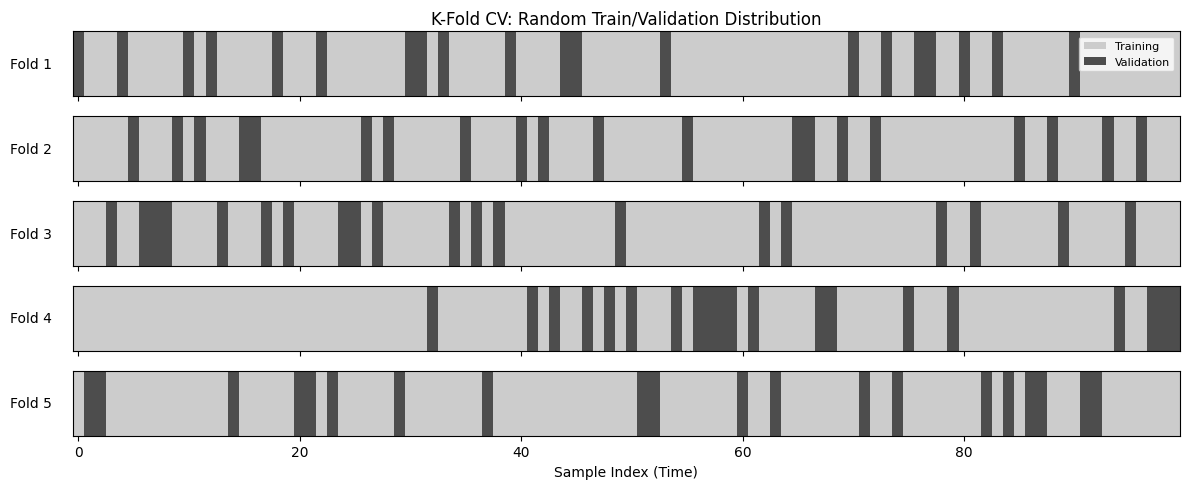

In [7]:
n_samples = 100
sample_indices = np.arange(n_samples)

kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)

fig, axes = plt.subplots(5, 1, figsize=(12, 5), sharex=True)

for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(sample_indices)):
    ax = axes[fold_idx]
    colors = np.zeros(n_samples)
    colors[val_idx] = 1

    for i in range(n_samples):
        color = "0.3" if colors[i] == 1 else "0.8"
        ax.bar(i, 1, width=1, color=color, edgecolor="none")

    ax.set_ylabel(f"Fold {fold_idx + 1}", rotation=0, labelpad=30, va="center")
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlim(-0.5, n_samples - 0.5)

axes[-1].set_xlabel("Sample Index (Time)")
axes[0].set_title("K-Fold CV: Random Train/Validation Distribution")
axes[0].legend(
    handles=[Patch(facecolor="0.8", label="Training"), Patch(facecolor="0.3", label="Validation")],
    loc="upper right",
    fontsize=8,
)
fig.tight_layout()
fig.show()

In Fold 1, the model trains on samples from the future (indices 80–100) to
predict the past. This violates decision-time admissibility.

---

## 4. Walk-Forward Cross-Validation

**Walk-forward CV** respects temporal ordering: training always **precedes**
validation. Two variants — **expanding** and **rolling** windows.

We use `WalkForwardCV` from `ml4t.diagnostic.splitters` to generate the
actual folds on NYSE trading sessions.

### Expanding Window

Training grows with each fold — uses all available history.

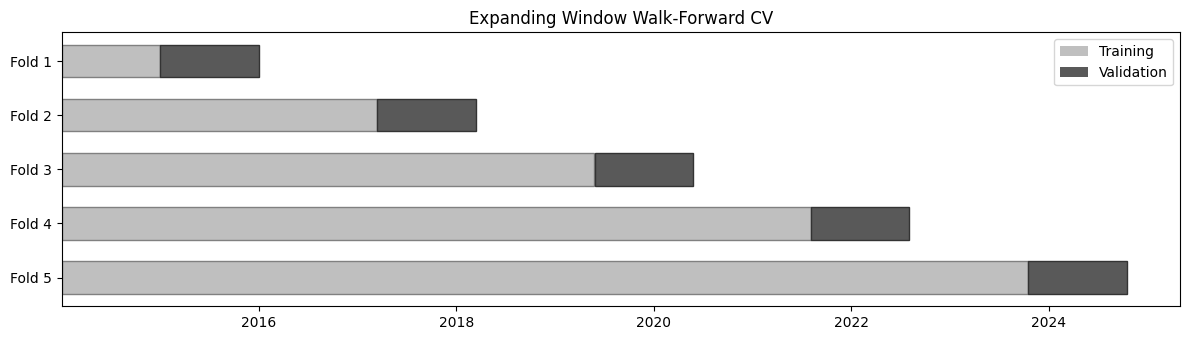

In [8]:
cv_exp = WalkForwardCV(n_splits=5, test_size=252, expanding=True)
splits_exp = list(cv_exp.split(df_dates))

fig = plot_splits(splits_exp, dates, title="Expanding Window Walk-Forward CV")
fig.show()

**Advantage**: Uses all available data. **Disadvantage**: Training set size
varies, which can affect model behavior.

### Rolling Window

Fixed training window — old data drops off as we move forward.

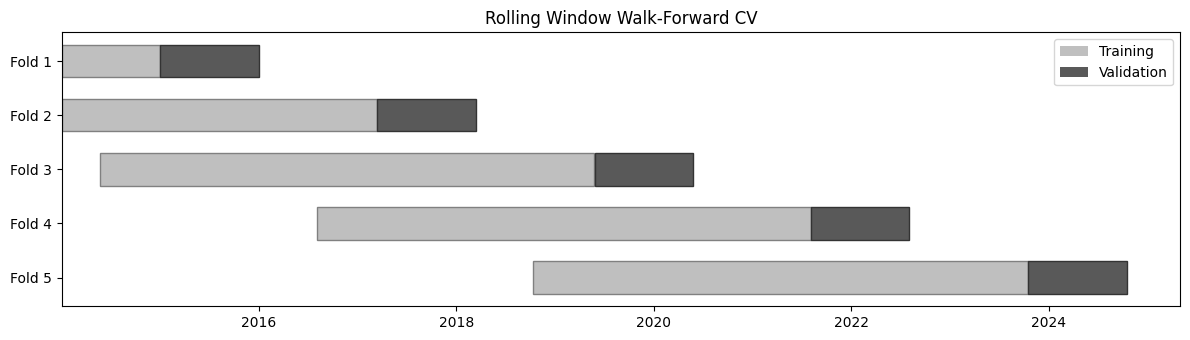

In [9]:
cv_roll = WalkForwardCV(n_splits=5, test_size=252, train_size=1260, expanding=False)
splits_roll = list(cv_roll.split(df_dates))

fig = plot_splits(splits_roll, dates, title="Rolling Window Walk-Forward CV")
fig.show()

**Advantage**: Consistent training size; stale data doesn't influence the model.
**Disadvantage**: Discards data. Choose expanding if older data is still
relevant, rolling if you believe regimes change.

---

## 5. Label Buffer (Purging)

Walk-forward CV respects temporal order, but there's a subtler problem:
**labels take time to materialize**. A 21-day forward return label computed
at time $t$ uses prices from $t$ to $t+21$. If validation starts at $t+10$,
the training label has "seen" 11 validation-period prices.

This is **label leakage** — the most common form of look-ahead bias.

### Visualizing the Overlap Problem

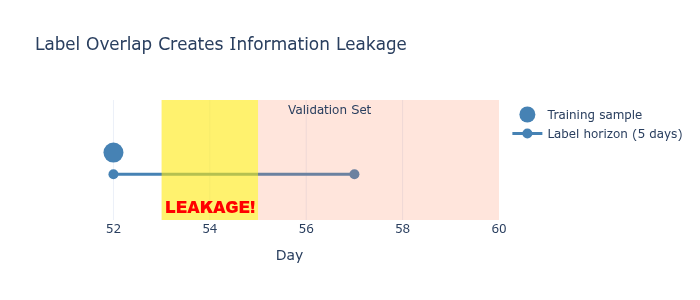

In [10]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=[52],
        y=[0.5],
        mode="markers",
        marker=dict(size=20, color="steelblue"),
        name="Training sample",
    )
)
fig.add_trace(
    go.Scatter(
        x=[52, 57],
        y=[0.4, 0.4],
        mode="lines+markers",
        line=dict(color="steelblue", width=3),
        marker=dict(size=10),
        name="Label horizon (5 days)",
    )
)
fig.add_vrect(x0=53, x1=60, fillcolor="coral", opacity=0.2, line_width=0)
fig.add_annotation(x=56.5, y=0.7, text="Validation Set", showarrow=False, font=dict(size=12))

fig.add_vrect(x0=53, x1=55, fillcolor="yellow", opacity=0.5, line_width=0)
fig.add_annotation(
    x=54,
    y=0.25,
    text="LEAKAGE!",
    showarrow=False,
    font=dict(color="red", size=16, family="Arial Black"),
)

fig.update_layout(
    title="Label Overlap Creates Information Leakage",
    xaxis_title="Day",
    yaxis_visible=False,
    template="plotly_white",
    height=300,
    showlegend=True,
)
fig.show()

### The Solution: Label Buffer (Purge Gap)

End training at least $h$ samples before validation starts, where $h$ is the
label horizon. López de Prado (2018) calls this **purging**.

$$\text{Training End} \leq \text{Validation Start} - h$$

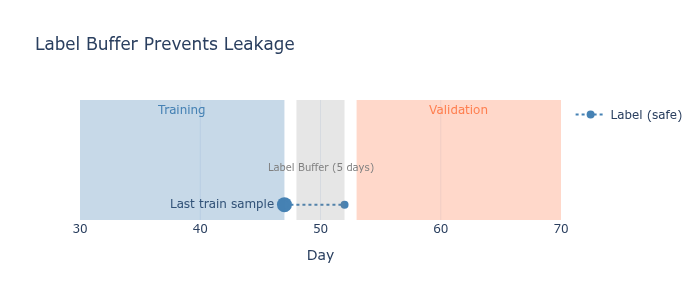

In [11]:
fig = go.Figure()

fig.add_vrect(x0=30, x1=47, fillcolor="steelblue", opacity=0.3, line_width=0)
fig.add_annotation(
    x=38.5, y=0.8, text="Training", showarrow=False, font=dict(size=12, color="steelblue")
)

fig.add_vrect(x0=48, x1=52, fillcolor="gray", opacity=0.2, line_width=0)
fig.add_annotation(
    x=50, y=0.5, text="Label Buffer\n(5 days)", showarrow=False, font=dict(size=10, color="gray")
)

fig.add_vrect(x0=53, x1=70, fillcolor="coral", opacity=0.3, line_width=0)
fig.add_annotation(
    x=61.5, y=0.8, text="Validation", showarrow=False, font=dict(size=12, color="coral")
)

fig.add_trace(
    go.Scatter(
        x=[47],
        y=[0.3],
        mode="markers+text",
        marker=dict(size=15, color="steelblue"),
        text=["Last train sample"],
        textposition="middle left",
        name="Training",
        showlegend=False,
    )
)
fig.add_trace(
    go.Scatter(
        x=[47, 52],
        y=[0.3, 0.3],
        mode="lines+markers",
        line=dict(color="steelblue", width=2, dash="dot"),
        marker=dict(size=8),
        name="Label (safe)",
    )
)

fig.update_layout(
    title="Label Buffer Prevents Leakage",
    xaxis_title="Day",
    yaxis_visible=False,
    template="plotly_white",
    height=300,
    showlegend=True,
)
fig.show()

### Walk-Forward CV with Label Buffer

`WalkForwardCV` implements label buffer via the `label_horizon` parameter.
With `calendar='XNYS'`, the gap is counted in **NYSE trading days**.

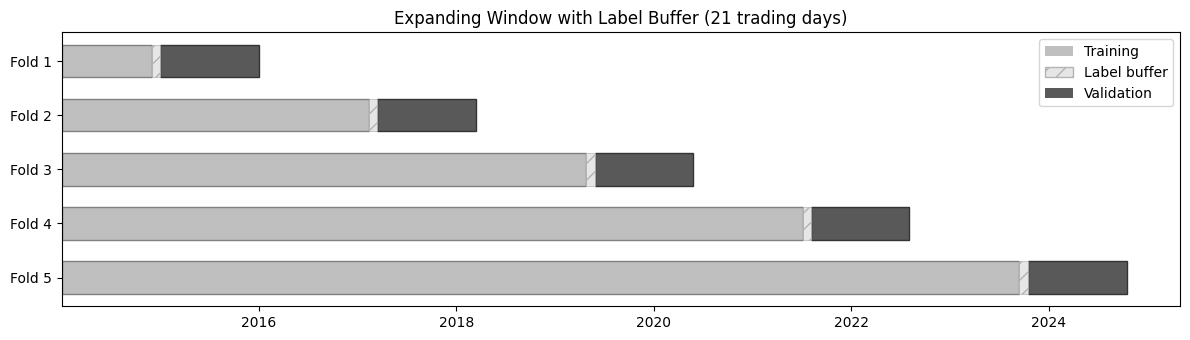

In [12]:
# Expanding with 21-day label buffer
cv_purge_exp = WalkForwardCV(
    n_splits=5,
    test_size=252,
    expanding=True,
    label_horizon=21,
    calendar="XNYS",
)
splits_purge_exp = list(cv_purge_exp.split(df_dates))

fig = plot_splits(
    splits_purge_exp, dates, title="Expanding Window with Label Buffer (21 trading days)"
)
fig.show()

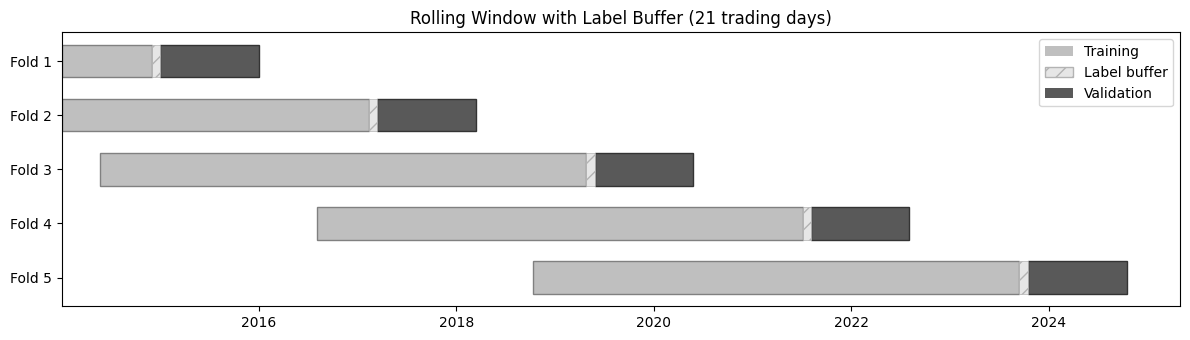

In [13]:
# Rolling with 21-day label buffer
cv_purge_roll = WalkForwardCV(
    n_splits=5,
    test_size=252,
    train_size=1260,
    expanding=False,
    label_horizon=21,
    calendar="XNYS",
)
splits_purge_roll = list(cv_purge_roll.split(df_dates))

fig = plot_splits(
    splits_purge_roll, dates, title="Rolling Window with Label Buffer (21 trading days)"
)
fig.show()

The hatched regions are **label buffer gaps**: 21 NYSE trading days where
training labels would overlap with validation. These samples are excluded
from training but not used for validation — they are simply discarded.

---

## 6. Feature Buffer (Embargo)

The label buffer prevents **forward-looking** leakage: training labels that
peek into the validation period. But there is a second leakage channel:
**backward-looking features** computed from validation data that bleed into
training.

This matters in **CPCV** and **k-fold** schemes where a training block can
appear *after* a validation block in calendar time. A 60-day rolling feature
computed for the first training sample after the validation block uses 60 days
of validation-period prices.

López de Prado (2018) calls this the **embargo**.

| Buffer | Direction | Protects Against | When It Matters |
|---|---|---|---|
| **Label buffer** (purge) | Forward-looking | Training labels peeking into validation | Always |
| **Feature buffer** (embargo) | Backward-looking | Training features using validation data | CPCV, k-fold |

In pure walk-forward CV (training always precedes validation), the feature
buffer is **zero** because no training sample follows a validation block.

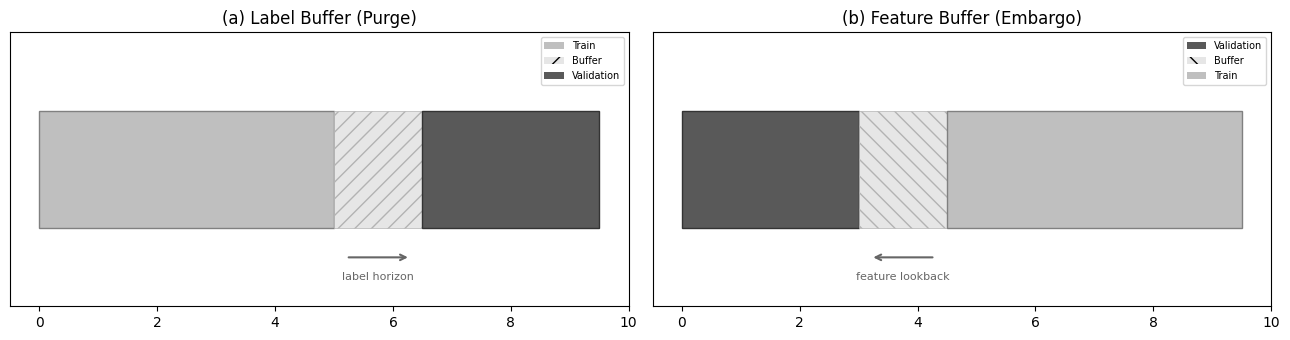

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

# Panel (a): Label buffer — forward-looking
ax = axes[0]
ax.barh(1, 5, left=0, height=0.6, color="0.75", edgecolor="0.5")
ax.barh(1, 1.5, left=5, height=0.6, color="0.9", edgecolor="0.7", hatch="//", linewidth=0.5)
ax.barh(1, 3, left=6.5, height=0.6, color="0.35", edgecolor="0.2")
ax.annotate(
    "", xy=(6.3, 0.55), xytext=(5.2, 0.55), arrowprops=dict(arrowstyle="->", color="0.4", lw=1.5)
)
ax.text(5.75, 0.45, "label horizon", ha="center", va="center", fontsize=8, color="0.4")
ax.set_xlim(-0.5, 10)
ax.set_ylim(0.3, 1.7)
ax.set_yticks([])
ax.set_title("(a) Label Buffer (Purge)")
ax.legend(
    handles=[
        Patch(facecolor="0.75", label="Train"),
        Patch(facecolor="0.9", hatch="//", label="Buffer"),
        Patch(facecolor="0.35", label="Validation"),
    ],
    fontsize=7,
    loc="upper right",
)

# Panel (b): Feature buffer — backward-looking (CPCV scenario)
ax = axes[1]
ax.barh(1, 3, left=0, height=0.6, color="0.35", edgecolor="0.2")
ax.barh(1, 1.5, left=3, height=0.6, color="0.9", edgecolor="0.7", hatch="\\\\", linewidth=0.5)
ax.barh(1, 5, left=4.5, height=0.6, color="0.75", edgecolor="0.5")
ax.annotate(
    "", xy=(3.2, 0.55), xytext=(4.3, 0.55), arrowprops=dict(arrowstyle="->", color="0.4", lw=1.5)
)
ax.text(3.75, 0.45, "feature lookback", ha="center", va="center", fontsize=8, color="0.4")
ax.set_xlim(-0.5, 10)
ax.set_ylim(0.3, 1.7)
ax.set_yticks([])
ax.set_title("(b) Feature Buffer (Embargo)")
ax.legend(
    handles=[
        Patch(facecolor="0.35", label="Validation"),
        Patch(facecolor="0.9", hatch="\\\\", label="Buffer"),
        Patch(facecolor="0.75", label="Train"),
    ],
    fontsize=7,
    loc="upper right",
)

fig.tight_layout()
fig.show()

**(a)** In walk-forward, training precedes validation. The label buffer
removes training samples whose labels extend into the validation period.

**(b)** In CPCV, a training block can follow a validation block. The feature
buffer removes training samples whose backward-looking features use
validation data.

---

## 7. Calendar-Aware Cross-Validation

A **critical subtlety**: financial markets don't trade every calendar day.
The NYSE has ~252 trading days per year, not 365. When we specify a label
horizon of 21 days for monthly forward returns, we mean **21 trading days**.

### The Problem: Naive Calendar-Day Purging

January 2024 has 31 calendar days but only 21 NYSE trading days.
A naive 21-calendar-day purge before February 1 (Jan 11-31) only removes 14
trading days — allowing 7 trading days of leakage.

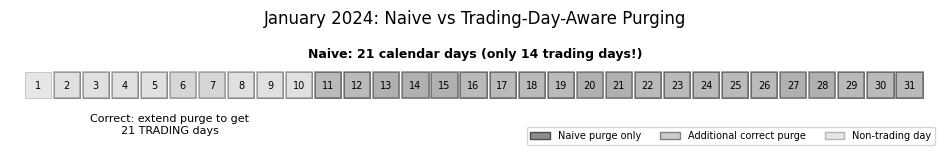

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))

jan_dates = pd.date_range("2024-01-01", "2024-01-31", freq="D")
holidays = pd.to_datetime(["2024-01-01", "2024-01-15"])  # New Year's, MLK Day

for i, d in enumerate(jan_dates):
    is_weekend = d.dayofweek >= 5
    is_holiday = d in holidays
    is_non_trading = is_weekend or is_holiday

    color = "0.9" if is_non_trading else "white"
    edge = "0.7" if is_non_trading else "0.4"
    rect = Rectangle((i, 0), 0.9, 0.9, facecolor=color, edgecolor=edge, linewidth=0.5)
    ax.add_patch(rect)
    ax.text(i + 0.45, 0.45, str(d.day), ha="center", va="center", fontsize=7)

# Naive purge region (Jan 11-31 = 21 calendar days before Feb 1)
for i in range(10, 31):
    rect = Rectangle(
        (i, 0),
        0.9,
        0.9,
        facecolor="0.55",
        edgecolor="0.3",
        linewidth=1.2,
        alpha=0.6,
        zorder=2,
    )
    ax.add_patch(rect)

# Correct additional purge (Jan 2-10)
for i in range(1, 10):
    rect = Rectangle(
        (i, 0),
        0.9,
        0.9,
        facecolor="0.8",
        edgecolor="0.5",
        linewidth=1.2,
        alpha=0.6,
        zorder=2,
    )
    ax.add_patch(rect)

ax.text(
    15.5,
    1.4,
    "Naive: 21 calendar days (only 14 trading days!)",
    ha="center",
    fontsize=9,
    fontweight="bold",
)
ax.text(5, -1.2, "Correct: extend purge to get\n21 TRADING days", ha="center", fontsize=8)

ax.set_xlim(-0.5, 31.5)
ax.set_ylim(-1.6, 1.9)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("January 2024: Naive vs Trading-Day-Aware Purging", pad=14)
ax.legend(
    handles=[
        Rectangle((0, 0), 1, 1, facecolor="0.55", edgecolor="0.3", label="Naive purge only"),
        Rectangle((0, 0), 1, 1, facecolor="0.8", edgecolor="0.5", label="Additional correct purge"),
        Rectangle((0, 0), 1, 1, facecolor="0.9", edgecolor="0.7", label="Non-trading day"),
    ],
    loc="lower right",
    bbox_to_anchor=(1.0, -0.05),
    fontsize=7,
    ncol=3,
)
fig.show()

**Rule**: Always count purge gaps in **trading days**, not calendar days.
`WalkForwardCV` handles this automatically when given a `calendar` parameter.

### Calendar-Aware Splits in Practice

Passing `calendar='XNYS'` ensures `WalkForwardCV` counts the label buffer
in NYSE trading days, skipping weekends and holidays.

In [16]:
# Calendar-aware splits: 21 trading-day label buffer
cv_nyse = WalkForwardCV(
    n_splits=3, test_size=252, expanding=True, label_horizon=21, calendar="XNYS"
)
splits_nyse = list(cv_nyse.split(df_dates))

print("Walk-forward with 21 trading-day label buffer (NYSE calendar):\n")
for i, (tr, va) in enumerate(splits_nyse):
    gap_sessions = va[0] - tr[-1]
    train_end_date = dates[tr[-1]]
    val_start_date = dates[va[0]]
    gap_calendar = (val_start_date - train_end_date).days
    print(f"  Fold {i + 1}: train ends {train_end_date.date()}, val starts {val_start_date.date()}")
    print(f"          gap = {gap_sessions} trading days ({gap_calendar} calendar days)")

Walk-forward with 21 trading-day label buffer (NYSE calendar):

  Fold 1: train ends 2014-12-01, val starts 2015-01-02
          gap = 22 trading days (32 calendar days)
  Fold 2: train ends 2018-07-31, val starts 2018-08-30
          gap = 22 trading days (30 calendar days)
  Fold 3: train ends 2022-03-29, val starts 2022-04-29
          gap = 22 trading days (31 calendar days)


Each fold's label buffer spans 22 trading sessions, which covers ~30 calendar
days due to weekends and holidays. A naive implementation that counts 21
*calendar* days (e.g. Jan 11-31, 2024) would only purge 14 trading days —
leaving 7 days of label leakage. The `calendar='XNYS'` parameter ensures the
gap is measured in actual trading days.

---

## 8. Nested Walk-Forward

Standard walk-forward CV tunes hyperparameters on one validation period
(e.g., 2019–2023), then tests once on the holdout (2024–2025). By the time
we reach 2025, those hyperparameters may be stale.

**Nested walk-forward** adds an **outer loop** that rolls the test window
forward, retuning hyperparameters at each step.

- **Inner loop**: Walk-forward CV selects hyperparameters $\lambda^*$
- **Outer loop**: Advances the test window and reruns the inner loop

This produces **multiple test points**, each with freshly tuned
hyperparameters — capturing tuning instability over time.

In [17]:
# Two outer folds: test on 2024 (tune on 2019-2023), test on 2025 (tune on 2020-2024)
nested_folds = []

for fold in range(5):
    val_year = 2019 + fold
    nested_folds.append(
        {
            "Outer": 1,
            "Inner Fold": fold + 1,
            "Train": f"2014–{val_year - 1}",
            "Validation": str(val_year),
            "Test": 2024,
        }
    )

for fold in range(5):
    val_year = 2020 + fold
    nested_folds.append(
        {
            "Outer": 2,
            "Inner Fold": fold + 1,
            "Train": f"2014–{val_year - 1}",
            "Validation": str(val_year),
            "Test": 2025,
        }
    )

pd.DataFrame(nested_folds)

,Outer,Inner Fold,Train,Validation,Test
0,1,1,2014–2018,2019,2024
1,1,2,2014–2019,2020,2024
2,1,3,2014–2020,2021,2024
3,1,4,2014–2021,2022,2024
4,1,5,2014–2022,2023,2024
5,2,1,2014–2019,2020,2025
6,2,2,2014–2020,2021,2025
7,2,3,2014–2021,2022,2025
8,2,4,2014–2022,2023,2025
9,2,5,2014–2023,2024,2025


### Nested Walk-Forward Timeline

Each outer fold runs a full inner walk-forward CV to select
$\lambda^*$, then evaluates on its test year.

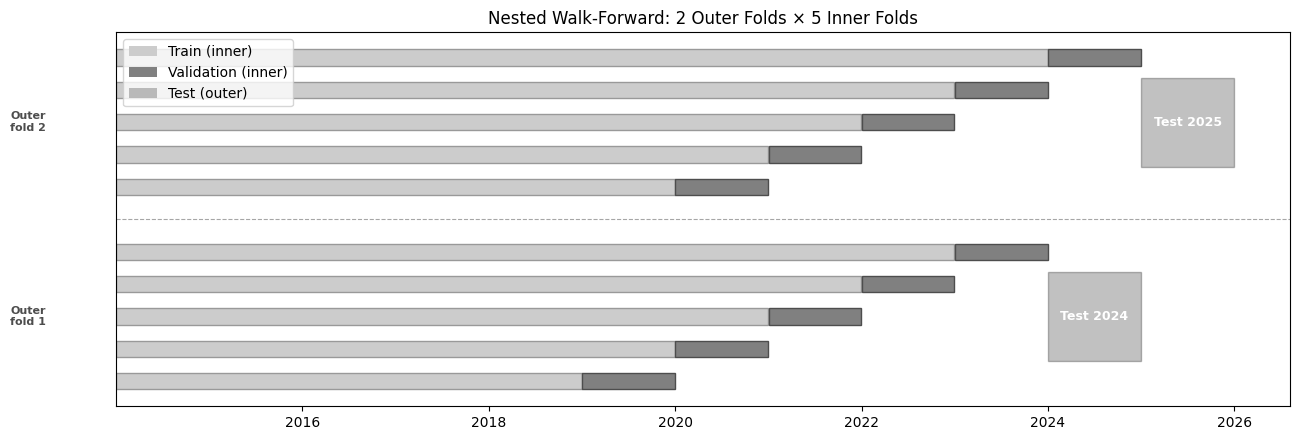

In [18]:
fig, ax = plt.subplots(figsize=(13, 4.5))

outer_folds = [
    {"test_year": 2024, "val_years": list(range(2019, 2024)), "color_test": "0.2"},
    {"test_year": 2025, "val_years": list(range(2020, 2025)), "color_test": "0.2"},
]

y = 0
outer_boundaries = []
for oi, outer in enumerate(outer_folds):
    # Inner folds
    for fi, val_yr in enumerate(outer["val_years"]):
        y += 1
        train_s = pd.Timestamp("2014-01-02", tz="UTC")
        train_e = pd.Timestamp(f"{val_yr - 1}-12-31", tz="UTC")
        val_s = pd.Timestamp(f"{val_yr}-01-02", tz="UTC")
        val_e = pd.Timestamp(f"{val_yr}-12-31", tz="UTC")

        ax.barh(y, train_e - train_s, left=train_s, height=0.5, color="0.8", edgecolor="0.6")
        ax.barh(y, val_e - val_s, left=val_s, height=0.5, color="0.5", edgecolor="0.3")

    # Test bar (spans all inner folds visually)
    test_s = pd.Timestamp(f"{outer['test_year']}-01-02", tz="UTC")
    test_e = pd.Timestamp(f"{outer['test_year']}-12-31", tz="UTC")
    y_mid = y - len(outer["val_years"]) / 2 + 0.5
    ax.barh(
        y_mid,
        test_e - test_s,
        left=test_s,
        height=len(outer["val_years"]) * 0.55,
        color="0.2",
        edgecolor="0.1",
        alpha=0.3,
    )
    ax.text(
        test_s + (test_e - test_s) / 2,
        y_mid,
        f"Test {outer['test_year']}",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="white",
    )

    # Outer-fold group label (left of training bars)
    ax.text(
        pd.Timestamp("2013-04-01", tz="UTC"),
        y_mid,
        f"Outer\nfold {oi + 1}",
        ha="right",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="0.3",
    )

    outer_boundaries.append(y + 0.5)
    # Separator between outer folds
    if oi < len(outer_folds) - 1:
        y += 1.0

# Draw horizontal dividers between outer folds
for boundary in outer_boundaries[:-1]:
    ax.axhline(boundary + 0.5, color="0.5", linestyle="--", linewidth=0.8, alpha=0.7)

ax.set_yticks([])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.set_title("Nested Walk-Forward: 2 Outer Folds × 5 Inner Folds")
ax.legend(
    handles=[
        Patch(facecolor="0.8", label="Train (inner)"),
        Patch(facecolor="0.5", label="Validation (inner)"),
        Patch(facecolor="0.2", alpha=0.3, label="Test (outer)"),
    ],
    loc="upper left",
)
fig.tight_layout()
fig.show()

Each outer fold produces test predictions with freshly selected $\lambda^*$.
If $\lambda^*_1 \neq \lambda^*_2$, that signals hyperparameter instability —
a red flag for production deployment.

---

## 9. Combinatorial Purged CV (CPCV)

Walk-forward CV produces **one backtest path** — a single sequence of
out-of-sample predictions. That path might reflect luck.

**CPCV** divides time into $N$ contiguous blocks, holds out $k$ blocks for
validation, trains on the remaining $N - k$ (with purging at boundaries),
and repeats for all $\binom{N}{k}$ combinations. The validation predictions
are then assembled into **multiple complete backtest paths**, each covering
every time block exactly once.

Each path is a complete out-of-sample backtest — one prediction per block,
assembled from different splits so no block's prediction depends on its own
training data.

In [19]:
N, K = 6, 2
n_splits = comb(N, K)  # C(6,2) = 15
n_paths = (K * n_splits) // N  # = 5

print(f"N={N} blocks, k={K} held out → {n_splits} splits, {n_paths} backtest paths")

N=6 blocks, k=2 held out → 15 splits, 5 backtest paths


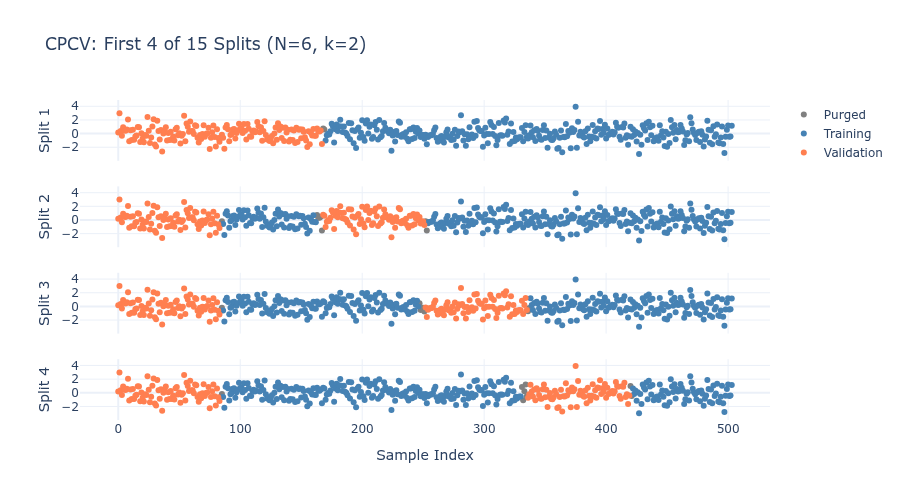

In [20]:
# Visualize first 4 splits
set_global_seeds(SEED)
X_viz = np.random.randn(N_VIZ, 5)
y_viz = np.random.randn(N_VIZ)

cv_cpcv = CombinatorialCV(n_groups=6, n_test_groups=2, label_horizon=5, embargo_size=2)
splits_cpcv = list(cv_cpcv.split(X_viz))

fig = make_subplots(rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.08)

for split_idx in range(min(4, len(splits_cpcv))):
    train_idx, val_idx = splits_cpcv[split_idx]
    split_type = np.zeros(N_VIZ)
    split_type[train_idx] = 1
    split_type[val_idx] = 2

    for stype, (color, label) in enumerate(
        [("gray", "Purged"), ("steelblue", "Training"), ("coral", "Validation")]
    ):
        mask = split_type == stype
        if np.any(mask):
            fig.add_trace(
                go.Scatter(
                    x=np.arange(N_VIZ)[mask],
                    y=y_viz[mask],
                    mode="markers",
                    marker=dict(color=color, size=6),
                    name=label if split_idx == 0 else None,
                    showlegend=(split_idx == 0),
                ),
                row=split_idx + 1,
                col=1,
            )
    fig.update_yaxes(title_text=f"Split {split_idx + 1}", row=split_idx + 1, col=1)

fig.update_layout(
    title=f"CPCV: First 4 of {n_splits} Splits (N={N}, k={K})",
    height=500,
    width=900,
    template="plotly_white",
    showlegend=True,
    margin=dict(l=80),
)
fig.update_xaxes(title_text="Sample Index", row=4, col=1)
fig.update_yaxes(title_standoff=8)
fig.show()

Gray regions are samples removed by the label buffer (purge) and feature
buffer (embargo) at block boundaries. With $N=6$, $k=2$: 15 splits produce
5 independent backtest paths.

If all paths show similar Sharpe ratios → robust. If they vary wildly →
path-dependent (possibly overfit). Bailey et al. (2014) formalize this into
the **Probability of Backtest Overfitting (PBO)** — the fraction of paths
whose in-sample rank doesn't hold out-of-sample. We return to PBO in
Chapter 17 when assembling full backtest results.

---

## 10. Putting It Together

### CV Method Comparison

| Method | Paths | Label Buffer | Feature Buffer | When to Use |
|---|---|---|---|---|
| Walk-Forward | 1 | Yes | No (train < val) | Standard evaluation |
| Nested Walk-Forward | 1 per test year | Yes | No | Multi-year test with retuning |
| CPCV | Multiple | Yes | Yes | Robustness testing (Ch17) |

### From Config to Protocol

`WalkForwardConfig` encodes all CV design decisions in a single object.
Each case study's `config/setup.yaml` stores these commitments; downstream
notebooks load them via `get_cv_config()`.

In [21]:
config = WalkForwardConfig(
    n_splits=5,
    test_size=252,
    train_size=1260,
    label_horizon=21,
    fold_direction="forward",
    calendar_id="NYSE",
)

config_table = pd.DataFrame(
    {
        "Parameter": list(config.model_dump().keys()),
        "Value": [str(v) for v in config.model_dump().values()],
    }
)
config_table

,Parameter,Value
0,n_splits,5
1,label_horizon,21
2,embargo_td,None
3,align_to_sessions,False
4,session_col,session_date
5,timestamp_col,None
6,filter_non_trading,True
7,isolate_groups,False
8,test_size,252
9,train_size,1260


### Loading a Case Study Protocol

Each case study stores its CV protocol in `case_studies/{id}/config/setup.yaml`.
The `get_cv_config()` function loads it into a `WalkForwardConfig`.

In [22]:
etf_config = get_cv_config("etfs")

print("ETF case study CV protocol:")
for k, v in etf_config.model_dump().items():
    print(f"  {k}: {v}")

ETF case study CV protocol:
  n_splits: 8
  train_size: 10Y
  test_size: 1Y
  embargo_td: P21D
  label_horizon: P21D
  timestamp_col: timestamp
  calendar_id: NYSE
  test_start: 2024-01-01
  test_end: 2025-12-31


This protocol specifies 8 walk-forward splits with 10-year rolling
training windows, 1-year test windows, and a 21-trading-day label buffer
(matching the 1-month forward return labels). The holdout period
(2024–2025) is sealed for final confirmation.

---

## Key Takeaways

### Decision-Time Admissibility
- The central constraint: only information available at decision time $t$
  can enter training for predictions at $t$
- Five leakage channels: label, standardization, threshold, survivorship,
  point-in-time

### Walk-Forward CV
- Training always precedes validation (respects temporal order)
- Expanding (all history) vs rolling (fixed window) — depends on regime beliefs

### Label Buffer (Purging)
- Forward-looking labels can leak validation data into training
- Remove training samples within one label horizon of validation start
- Count in **trading days** using a proper market calendar

### Feature Buffer (Embargo)
- Backward-looking features can leak validation data into training
- Matters in CPCV / k-fold where training follows validation in time
- Zero in pure walk-forward (training always precedes validation)

### Nested Walk-Forward
- Outer loop advances test window; inner loop retunes hyperparameters
- Captures tuning instability — $\lambda^*$ should be stable across periods

### Combinatorial Purged CV
- Multiple backtest paths from the same data reveal robustness
- Connects to Probability of Backtest Overfitting (Bailey et al. 2014)
- Full treatment in Chapter 17

**Next**: See `case_studies/*/01_feasibility_analysis.py` for applying these concepts
to real trading strategies.